<a href="https://www.kaggle.com/code/riteshkumarweb/accuracy-vs-confusion-matrix-binary?scriptVersionId=313848555" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/andrewmvd/heart-failure-clinical-data/heart_failure_clinical_records_dataset.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/andrewmvd/heart-failure-clinical-data/heart_failure_clinical_records_dataset.csv')

In [44]:
# Confusion Matrix:
#A confusion matrix is a table used to evaluate classification model performance.
# It shows how many predictions are correct and how many are wrong.
# It contains:
# TP = True Positive   -> Model correctly predicted Positive
# TN = True Negative   -> Model correctly predicted Negative
# FP = False Positive  -> Model wrongly predicted Positive
# FN = False Negative  -> Model wrongly predicted Negative

# Example:
# In disease prediction:
# TP -> Sick person predicted as Sick
# TN -> Healthy person predicted as Healthy
# FP -> Healthy person predicted as Sick
# FN -> Sick person predicted as Healthy


# Accuracy:
# Accuracy tells how many total predictions are correct out of all predictions made.

# Formula:
# Accuracy = (TP + TN) / (TP + TN + FP + FN)

# Example:
# If model correctly predicts 85 out of 100 cases,
# then Accuracy = 85/100 = 85%


# When Accuracy is Misleading:
# Accuracy becomes misleading when the dataset is imbalanced.

# Example:
# Suppose:
# 990 people are Healthy
# 10 people are Sick

# Model predicts everyone as Healthy

# Accuracy = 990 / 1000 = 99%

# This looks excellent, but actually the model is bad
# because it failed to detect all sick patients.

# In such cases, we should also check:
# Precision
# Recall
# F1 Score
# Confusion Matrix

# because high Accuracy does not always mean a good model.

In [4]:
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [5]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [9]:
df['DEATH_EVENT'].value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

In [10]:
df.corr()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
age,1.000000,0.088006,-0.081584,-0.101012,0.060098,0.093289,-0.052354,0.159187,-0.045966,0.065430,0.018668,-0.224068,0.253729
anaemia,0.088006,1.000000,-0.190741,-0.012729,0.031557,0.038182,-0.043786,0.052174,0.041882,-0.094769,-0.107290,-0.141414,0.066270
creatinine_phosphokinase,-0.081584,-0.190741,1.000000,-0.009639,-0.044080,-0.070590,0.024463,-0.016408,0.059550,0.079791,0.002421,-0.009346,0.062728
diabetes,-0.101012,-0.012729,-0.009639,1.000000,-0.004850,-0.012732,0.092193,-0.046975,-0.089551,-0.157730,-0.147173,0.033726,-0.001943
ejection_fraction,0.060098,0.031557,-0.044080,-0.004850,1.000000,0.024445,0.072177,-0.011302,0.175902,-0.148386,-0.067315,0.041729,-0.268603
high_blood_pressure,0.093289,0.038182,-0.070590,-0.012732,0.024445,1.000000,0.049963,-0.004935,0.037109,-0.104615,-0.055711,-0.196439,0.079351
platelets,-0.052354,-0.043786,0.024463,0.092193,0.072177,0.049963,1.000000,-0.041198,0.062125,-0.125120,0.028234,0.010514,-0.049139
serum_creatinine,0.159187,0.052174,-0.016408,-0.046975,-0.011302,-0.004935,-0.041198,1.000000,-0.189095,0.006970,-0.027414,-0.149315,0.294278
serum_sodium,-0.045966,0.041882,0.059550,-0.089551,0.175902,0.037109,0.062125,-0.189095,1.000000,-0.027566,0.004813,0.087640,-0.195204
sex,0.065430,-0.094769,0.079791,-0.157730,-0.148386,-0.104615,-0.125120,0.006970,-0.027566,1.000000,0.445892,-0.015608,-0.004316


In [12]:
df.corr()['DEATH_EVENT'].sort_values()

time                       -0.526964
ejection_fraction          -0.268603
serum_sodium               -0.195204
platelets                  -0.049139
smoking                    -0.012623
sex                        -0.004316
diabetes                   -0.001943
creatinine_phosphokinase    0.062728
anaemia                     0.066270
high_blood_pressure         0.079351
age                         0.253729
serum_creatinine            0.294278
DEATH_EVENT                 1.000000
Name: DEATH_EVENT, dtype: float64

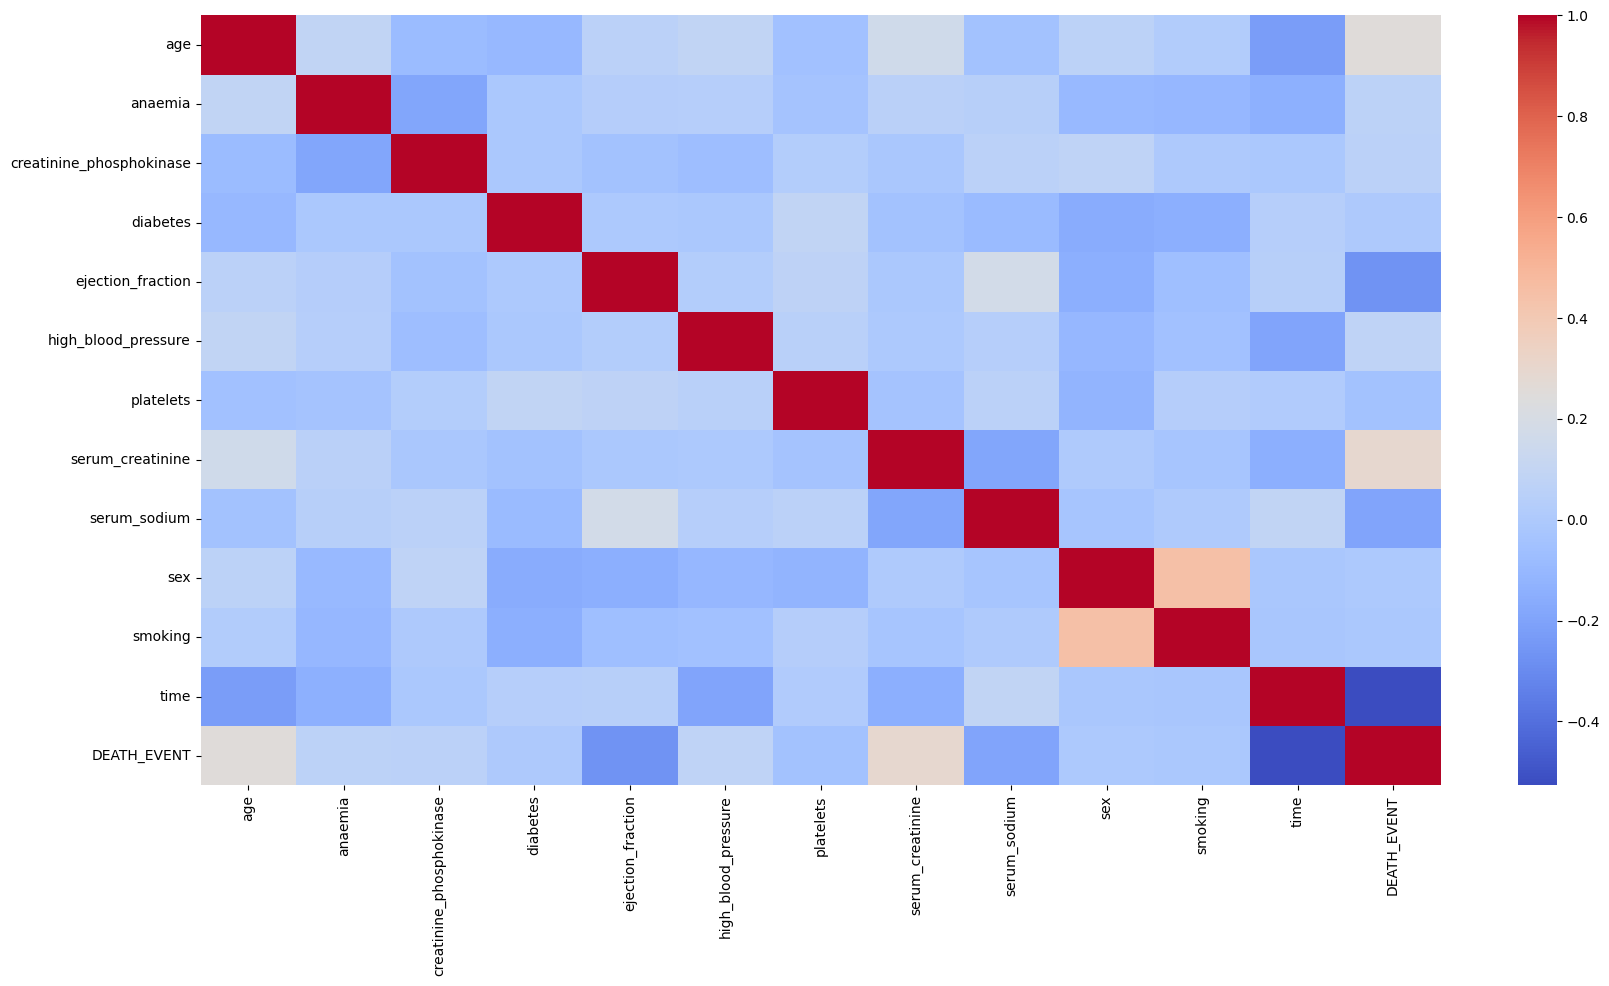

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

<Axes: xlabel='DEATH_EVENT', ylabel='serum_creatinine'>

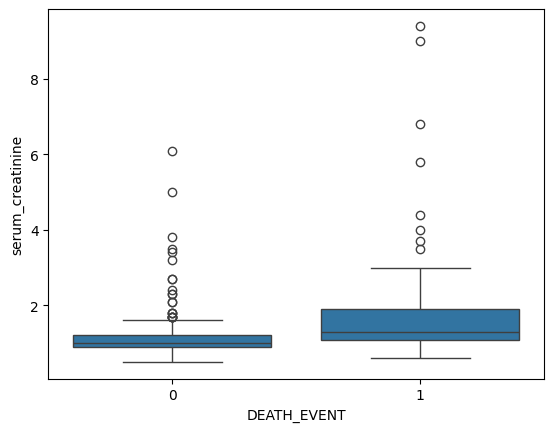

In [15]:
import seaborn as sns 
sns.boxplot(x='DEATH_EVENT', y='serum_creatinine', data=df)

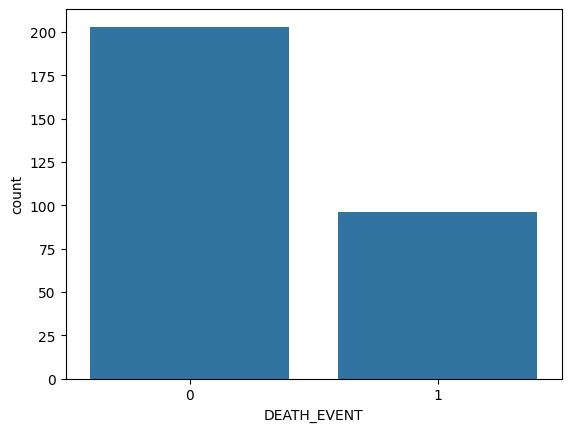

In [16]:
sns.countplot(x="DEATH_EVENT", data=df)
plt.show()

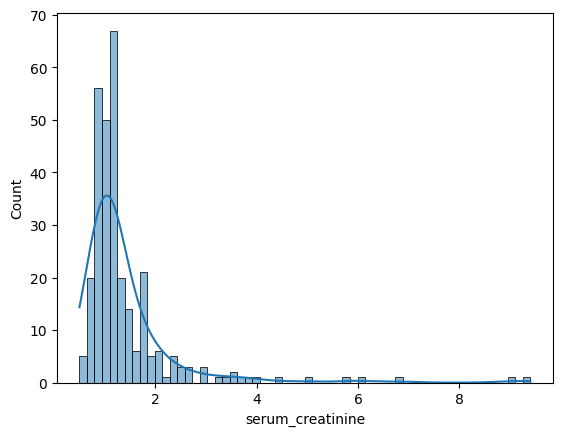

In [18]:
sns.histplot(df["serum_creatinine"], kde=True)
plt.show()

In [19]:
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [22]:
X = df.iloc[:,0:12]
X

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8
...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280


In [23]:
y = df.iloc[:,-1]
y

0      1
1      1
2      1
3      1
4      1
      ..
294    0
295    0
296    0
297    0
298    0
Name: DEATH_EVENT, Length: 299, dtype: int64

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Import the class
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


# Step 1: Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Step 2: Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [25]:
model1 = LogisticRegression()
model2 = DecisionTreeClassifier()

In [26]:
model1.fit(X_train,y_train)
model2.fit(X_train,y_train)

DecisionTreeClassifier()

In [27]:
y_predict1 = model1.predict(X_test)
y_predict2 = model2.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score,confusion_matrix

score = accuracy_score(y_test, y_predict1)
print(f"Accuracy Score: {score:.2f} | It means {score*100:.2f}% predictions of Logistic_Regression")

Accuracy Score: 0.80 | It means 80.00% predictions of Logistic_Regression


In [32]:
score = accuracy_score(y_test, y_predict2)
print(f"Accuracy Score: {score:.2f} | It means {score*100:.2f}% predictions of Decision Tree")

Accuracy Score: 0.65 | It means 65.00% predictions of Decision Tree


In [45]:
confusion_matrix(y_test , y_predict1)#Logistic_Regression

#Confusion Matrix shows Actual Values vs Predicted Values
# It helps us understand:
# ✅ How many predictions were correct
# ❌ Where the model got confused
# ⚠️ What type of mistakes the model made (FP and FN)

# That is why it is called "Confusion Matrix"

array([[34,  1],
       [11, 14]])

In [41]:
print("Logistic Regression Confusion Matrix\n")
pd.DataFrame(confusion_matrix(y_test,y_predict1),columns=list(range(0,2)))

Logistic Regression Confusion Matrix



,0,1
0,34,1
1,11,14


In [42]:
confusion_matrix(y_test, y_predict2) #Decision_Regression

array([[29,  6],
       [15, 10]])

In [43]:
print("Decision_Tree Confusion Matrix \n")
pd.DataFrame(confusion_matrix(y_test,y_predict2),columns=list(range(0,2)))

Decision_Tree Confusion Matrix 



,0,1
0,29,6
1,15,10
